In [3]:
1+1

2

In [4]:
import pandas as pd

df = pd.read_csv(r'C:\Users\krist\OneDrive\Desktop\bot-classifier\reddit_dead_internet_analysis_2026.csv')

print(df.shape)
print(df.columns.tolist())
print(df.head())

(500, 11)
['comment_id', 'subreddit', 'account_age_days', 'user_karma', 'reply_delay_seconds', 'sentiment_score', 'avg_word_length', 'contains_links', 'is_bot_flag', 'bot_type_label', 'bot_probability']
      comment_id subreddit  account_age_days  user_karma  reply_delay_seconds  \
0  t1_3148938807     funny              2264       34192                 1854   
1  t1_2516748923    gaming              1654        2812                 1033   
2   t1_833922318  politics              2442       37109                 2703   
3  t1_3987809057     funny               168       32997                 2811   
4  t1_3931039688    gaming               801       25088                 1721   

   sentiment_score  avg_word_length  contains_links  is_bot_flag  \
0            -0.60             4.62           False        False   
1             0.15             5.84           False        False   
2             0.35             5.73           False        False   
3            -0.74             4.58   

Class balance:
is_bot_flag
False    282
True     218
Name: count, dtype: int64

Model Results:
              precision    recall  f1-score   support

       Human       1.00      1.00      1.00        52
         Bot       1.00      1.00      1.00        48

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



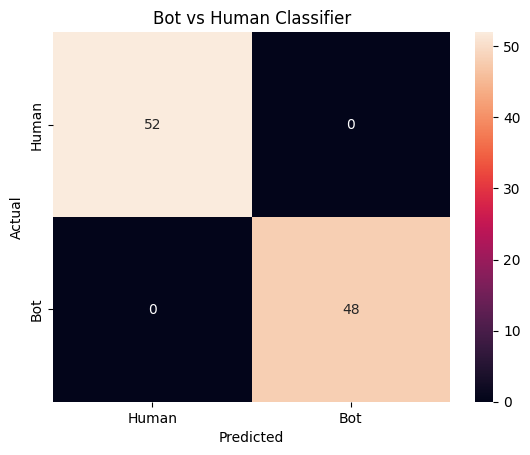

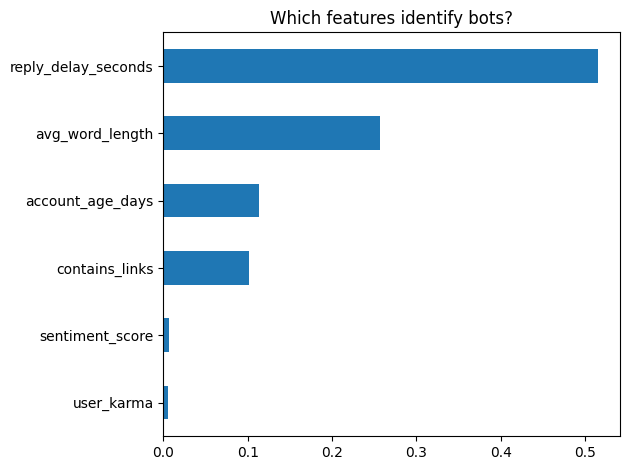

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Features and target
features = ['account_age_days', 'user_karma', 'reply_delay_seconds', 
            'sentiment_score', 'avg_word_length', 'contains_links']

X = df[features]
y = df['is_bot_flag']

# Check class balance
print("Class balance:")
print(y.value_counts())

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print("\nModel Results:")
print(classification_report(y_test, y_pred, target_names=['Human', 'Bot']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Human', 'Bot'], yticklabels=['Human', 'Bot'])
plt.title('Bot vs Human Classifier')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Feature importance
importances = pd.Series(model.feature_importances_, index=features).sort_values()
importances.plot(kind='barh', title='Which features identify bots?')
plt.tight_layout()
plt.show()